# Feature Sifting — adaptive generate-and-test

This notebook studies the **feature sifting** task (`phd/jax_core/tasks/feature_sifting.py`): an online
single-sample regression problem where the learner observes `n_learner_features` noisy candidate features,
each a noisy view of one of `n_target_features` true features. The target is a fixed weighted sum (weights
±1) of the true features, **plus Gaussian output noise of std 1.0**. The learner predicts the target with a
**linear model** and, each step, may mark candidate slots for replacement (`prune_mask`); pruned slots are
regenerated by the task with a fresh random target index and noise coefficient. The learner must continually
*sift* useful (low-noise) candidates from useless ones.

Every method here uses the **Autostep** (IDBD) optimizer as its base learner, and differs only in *how it
decides to throw a feature away* (its generate-and-test rule). Each method is a self-contained `eqx.Module`
— read the class and you see the entire method.

### Methods compared
1. **Autostep** — Autostep online linear regression on a **fixed** candidate set (never prunes). The baseline
   with no feature search.
2. **Autostep + Generate & Test (Autostep + G&T)** — the simplest utility-based pruner: every `prune_period`
   steps, drop the single lowest-magnitude weight (utility = `|weight|`) and regenerate that slot. Like CBP,
   but the utility is just the weight magnitude and pruning is on a fixed clock.
3. **Autostep + Adaptive G&T** — the same rule, but the clock slows itself down when the search stops paying
   off: whenever a prune event hits the **same slot as the previous prune event**, the prune period is
   multiplied by `1 + increase_frac` (e.g. 50 → 55 → 60.5 → 66.6 at 10%). Pruning the same slot twice in a
   row means the freshly generated feature was immediately the worst again, i.e. the generator is not
   producing anything better than what we already have — so search is annealed rather than run forever at a
   fixed rate. The period only ever grows; a prune event that lands on a different slot leaves it unchanged.

Beyond the per-method sweeps there are two dedicated studies:

* **Prune-period study (method 2)** — 30 seeds at each of a range of fixed prune periods (25 … 800 steps),
  at the best step-size / meta step-size found by the grid sweep, so the cost of pruning too eagerly vs. too
  lazily is visible directly in the learning curves.
* **Increase-fraction study (method 3)** — 30 seeds at each of 5%, 10%, 20%, 40%, 80% period growth, all
  starting from method 2's best configuration.

### How sweeping / caching works
Each method is run as an **mlflow-sweeper** grid sweep (programmatic `run_sweep`). Every configuration runs
`N` seeds batched in a single `jax.lax.scan` (jitted end-to-end) and logs the binned learning curve
(`loss`, `loss_std` = mean / std across seeds) plus a scalar `final_loss`; the confidence bands on the plots
are derived from that std at plot time. Because the sweeps and metrics
live in local MLflow/Optuna stores, **the experiments only run on the first execution** — re-running the
notebook finds the studies complete and just reloads the cached data.

In [1]:
import os
from dataclasses import dataclass

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import jax
import jax.numpy as jnp
import optax
import equinox as eqx
import mlflow
from omegaconf import OmegaConf

from mlflow_sweeper import SweepConfig, run_sweep, delete_sweep

from phd.jax_core.tasks.feature_sifting import FeatureSiftingTask
from phd.jax_core.optimizers.idbd import optax_idbd, IDBDState
from phd.jax_core.utils import tree_replace

from phd.research_utils.scripts.mlflow_download import download_experiment
from phd.research_utils.analysis.analysis_utils import (
    load_experiment_data, get_best_ablation_values, get_color_palette,
)

sns.set_theme('notebook', 'white')
%matplotlib inline

/home/edan/miniconda3/envs/jax/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Configuration

Storage is kept in local files **relative to this notebook**, so the sweep state and logged metrics persist
across runs. Adjust `NUM_STEPS` / seed counts / grids below to trade off runtime vs. resolution.

Two differences from the earlier step-size-protection notebook: the target output carries **noise of std
1.0** (so `1.0` is the irreducible loss — no method can go below it), and every run is **200k steps**.

In [ ]:
EXPERIMENT = 'feature_sifting_adaptive_gt'
NOTEBOOK_DIR = os.path.abspath('.')
DATA_DIR = os.path.join(NOTEBOOK_DIR, 'data')
SWEEP_OUTPUT_DIR = os.path.join(NOTEBOOK_DIR, 'sweep_output')

# MLFLOW_URI = f"sqlite:///{os.path.join(NOTEBOOK_DIR, 'output', 'mlruns.db')}"
# OPTUNA_URI = f"sqlite:///{os.path.join(NOTEBOOK_DIR, 'output', 'optuna.db')}"
# os.environ['MLFLOW_TRACKING_URI'] = MLFLOW_URI

MLFLOW_URI = os.environ['MLFLOW_TRACKING_URI']
OPTUNA_URI = os.environ['OPTUNA_STORAGE_URI']

mlflow.set_tracking_uri(MLFLOW_URI)
os.makedirs(DATA_DIR, exist_ok=True)
os.makedirs(SWEEP_OUTPUT_DIR, exist_ok=True)

# Task / training configuration.
N_TARGET_FEATURES = 10
N_LEARNER_FEATURES = 20
TARGET_NOISE_STD = 1.0
NUM_STEPS = 500_000
BASE_SEED = 0
N_SWEEP_SEEDS = 5       # seeds batched per sweep configuration
N_CURVE_SEEDS = 30      # seeds for the final best-config learning curves
N_LOG_POINTS = 250      # binned points logged per run (learning-curve resolution)
FINAL_FRACTION = 0.05   # last 5% of steps define the summary 'final loss'

# Prune periods studied for method 2 (one feature replaced every `p` steps, i.e. a replacement
# rate of 1/p features per step) and period growth fractions studied for method 3.
PRUNE_PERIODS = [25, 50, 100, 200, 400, 800]
INCREASE_FRACS = [0.05, 0.10, 0.20, 0.40, 0.80]
BASE_INCREASE_FRAC = 0.10

# Irreducible loss: the target output noise cannot be predicted, so E[(y_hat - y)^2] >= sigma^2
# even with a perfect feature set and perfect weights.
NOISE_FLOOR_LOSS = TARGET_NOISE_STD ** 2

# Loss of the trivial predictor (always predicts 0): E[y^2]. Each target weight is +-1
# and target features are uniform[-1, 1] (variance 1/3). Anything that learns beats this;
# anything that diverges exceeds it. Used as the convergence threshold for sensitivity plots.
BASELINE_LOSS = N_TARGET_FEATURES / 3.0 + TARGET_NOISE_STD ** 2

# Portion of the sweep config shared by every method.
BASE_SWEEP_CONFIG = {
    'experiment': EXPERIMENT,
    'optuna_storage': OPTUNA_URI,
    'mlflow_storage': MLFLOW_URI,
    'output_dir': SWEEP_OUTPUT_DIR,
    'algorithm': 'grid',
    'spec': {'direction': 'minimize', 'metric': 'final_loss'},
}
print('MLflow store :', MLFLOW_URI)
print('Noise floor  :', round(NOISE_FLOOR_LOSS, 4))
print('Baseline loss:', round(BASELINE_LOSS, 4))

MLflow store : sqlite:////home/edan/local_projects/phd_research/phd/sandbox/feature_sifting/exploration/output/mlruns.db
Noise floor  : 1.0
Baseline loss: 4.3333


## Core: the learner and shared primitives

A single linear layer `w` of shape `(1, n_learner_features)` predicts `y_hat = w · x` — the natural learner
for this task, and Autostep-compatible (2D weight, no bias). The loss is the squared prediction error on the
freshly observed sample.

**Method interface.** Each method (one per cell below) is an `eqx.Module` that bundles its own `init` and
`step`:

* `Method.init(hparams, key) -> Method` builds the Autostep optimizer, weights, and any algorithm state.
  Static hyperparameters (the optimizer, the prune period / constants) are `eqx.field(static=True)`; the
  dynamic state (weights, optimizer state, per-feature traces, …) are ordinary array fields.
* `method.step(x, y) -> (method, loss)` predicts, learns, and returns the updated module. It also carries a
  `prune_mask` field telling the task which candidate slots to regenerate next (all-`False` for methods that
  never recycle).

Only two things are shared across methods, and both are deliberately tiny so each method reads end-to-end on
its own: `linear_loss_and_grads` (the squared-error loss + gradient) and `reset_idbd_state` (put a pruned
slot's Autostep state back to initial, exactly as continual-backprop does when it recycles a feature).

In [3]:
def linear_loss_and_grads(w, x, y):
    """Squared-error loss of the linear prediction and its exact gradient wrt `w`."""
    y_hat = jnp.sum(w * x[None, :])
    error = y_hat - y
    return error ** 2, 2.0 * error * x[None, :]


def reset_idbd_state(opt_state, prune_mask):
    """Reset per-feature Autostep (IDBD) state for pruned / regenerated slots: step-size back
    to its initial value, and the gradient trace `h` and normaliser `v` to zero. `prune_mask` is
    a boolean array of shape (n_features,)."""
    m = prune_mask[None, :]   # broadcast over the single output row -> (1, n_features)
    return IDBDState(
        init_beta=opt_state.init_beta,
        beta=jnp.where(m, opt_state.init_beta, opt_state.beta),  # step-size -> initial
        h=jnp.where(m, 0.0, opt_state.h),
        v=jnp.where(m, 0.0, opt_state.v),
    )


def noise_floor(task):
    """Loss floor of the task's *current* feature set: for each of the ``n_target_features`` unique
    target features, the lowest noise coefficient among the candidate slots pointing at it (``1.0``
    for an uncovered target), summed. Lower-noise candidates covering more targets -> a lower floor,
    so this tracks the quality of the feature set a method has assembled."""
    target_idxs = jnp.arange(task.n_target_features)
    def min_noise_for_target(idx):
        points_here = task.learner_feature_idxs == idx
        return jnp.where(points_here.any(),
                         jnp.min(jnp.where(points_here, task.noise_coefficients, 1.0)),
                         1.0)
    return jnp.sum(jax.vmap(min_noise_for_target)(target_idxs))

## Sweep infrastructure

`MethodSpec` records a method's class, default hyperparameters, and label; each method registers itself in
`METHODS` from its own cell. `run_all_seeds` runs every seed of a config batched in a single jitted
`jax.lax.scan` — the loop only calls the module's `init` / `step` and routes `prune_mask` to the task.
`run_method_sweep` turns a grid into a programmatic mlflow-sweeper sweep (the objective fills in `defaults`
for any hyperparameter the grid does not sweep, and logs via `log_run`); `load_sweep_data` returns the
standard `config_dfs` / `run_dfs` dicts, downloading only when new runs have appeared. `plot_config_curves`
is the one addition: it plots one learning curve per value of a swept hyperparameter *within* a single
multi-configuration sweep, which is how the prune-period and increase-fraction studies are drawn.

Bands on the learning curves are **95% confidence intervals on the mean over seeds**: `plot_learning_curve`
derives them from the logged across-seed std via `ci_halfwidth` (t-based, so `t = 2.045` rather than
`z = 1.96` at 30 seeds) whenever it is told `n_seeds`. Nothing extra is logged, so the CI level can change
without re-running anything. Pass `show_ci=False` for the mean line alone, as the multi-curve studies do.

In [4]:
import sys
if NOTEBOOK_DIR not in sys.path:           # make the sibling experiment_logging.py importable
    sys.path.insert(0, NOTEBOOK_DIR)
from experiment_logging import log_run, summarize_runs, plot_sensitivity, plot_learning_curve


@dataclass
class MethodSpec:
    name: str          # mlflow sweep_name
    label: str         # human-readable label for plots
    cls: type          # eqx.Module with .init(hparams, key) and .step(x, y) -> (module, loss)
    defaults: dict     # default hyperparameters; the grid overrides the subset it sweeps


METHODS = {}           # each method's cell below registers itself here


def swept_vars(grid):
    """The grid keys that actually vary (more than one value) — the swept hyperparameters."""
    return [k for k, vals in grid.items() if isinstance(vals, (list, tuple)) and len(vals) > 1]


def run_all_seeds(method_cls, hparams, n_seeds):
    """Run `n_seeds` seeds (batched + jitted) of `method_cls` at `hparams`; losses (n_seeds, NUM_STEPS)."""
    def run_one_seed(seed_key):
        task_key, init_key = jax.random.split(seed_key)
        task = FeatureSiftingTask(N_TARGET_FEATURES, N_LEARNER_FEATURES, TARGET_NOISE_STD, key=task_key)
        state = method_cls.init(hparams, init_key)

        def scan_step(carry, _):
            task, state = carry
            task, (x, y) = task.step(state.prune_mask)     # task regenerates the recycled slots
            state, loss = state.step(x, jnp.squeeze(y))
            return (task, state), loss

        _, losses = jax.lax.scan(scan_step, (task, state), length=NUM_STEPS)
        return losses

    seed_keys = jax.random.split(jax.random.PRNGKey(BASE_SEED), n_seeds)
    return jax.jit(jax.vmap(run_one_seed))(seed_keys)


def make_objective(spec):
    def objective(**params):
        n_seeds = int(params.pop('n_seeds'))
        hparams = {**spec.defaults, **{k: float(v) for k, v in params.items()}}
        return log_run(run_all_seeds(spec.cls, hparams, n_seeds), N_LOG_POINTS, FINAL_FRACTION)
    return objective


def run_method_sweep(spec, grid, n_seeds, sweep_name=None, n_jobs=1, overwrite=False):
    sweep_name = sweep_name or spec.name
    params = dict(grid)
    params['n_seeds'] = int(n_seeds)
    cfg = {**BASE_SWEEP_CONFIG, 'sweep_name': sweep_name, 'parameters': params}
    config = SweepConfig.from_dict_config(OmegaConf.create(cfg))
    # End any lingering active run so re-running an already-complete sweep doesn't raise
    # "Run ... is already active".
    if mlflow.active_run() is not None:
        mlflow.end_run()

    if overwrite:
        delete_sweep(config)

    # allow_param_change updates the sweep in place when the config differs from the stored
    # one — e.g. after moving the MLflow/Optuna stores, or after editing a grid. Matching
    # trials are migrated (no recompute); only new/removed grid points actually run.
    run_sweep(config, make_objective(spec), n_jobs=n_jobs, log_params=True, no_plots=True,
              allow_param_change=True, executor='thread')


PARAMS_CSV = os.path.join(DATA_DIR, f'{EXPERIMENT}_params.csv')
METRICS_CSV = os.path.join(DATA_DIR, f'{EXPERIMENT}_metrics.csv')
RUN_COUNT_MARKER = os.path.join(DATA_DIR, f'.{EXPERIMENT}_run_count')


def _n_finished_runs():
    """Number of finished MLflow runs in the experiment (cheap; no metric history)."""
    client = mlflow.tracking.MlflowClient()
    exp = client.get_experiment_by_name(EXPERIMENT)
    if exp is None:
        return 0
    return len(client.search_runs([exp.experiment_id],
                                  filter_string="attributes.status = 'FINISHED'",
                                  max_results=50000))


def load_sweep_data(force_download=False):
    """Load the experiment's CSVs, downloading from MLflow only when needed.

    The download is skipped (cached CSVs are reloaded) whenever no new finished runs
    have appeared since the last download, so re-running analysis cells does not
    re-download. Pass ``force_download=True`` to force a fresh download.
    """
    n_runs = _n_finished_runs()
    have_csv = os.path.exists(PARAMS_CSV) and os.path.exists(METRICS_CSV)
    cached_n = int(open(RUN_COUNT_MARKER).read()) if os.path.exists(RUN_COUNT_MARKER) else -1
    if force_download or not have_csv or n_runs != cached_n:
        download_experiment(EXPERIMENT, output_dir=DATA_DIR, tracking_uri=MLFLOW_URI)
        with open(RUN_COUNT_MARKER, 'w') as f:
            f.write(str(n_runs))
    else:
        print(f'Reusing cached CSVs ({n_runs} runs, no new data to download).')
    return load_experiment_data(PARAMS_CSV, METRICS_CSV)


def best_hparams(cfgs, runs, spec, grid):
    """Best (min final-avg loss) hyperparameters for a method's grid sweep."""
    sv = swept_vars(grid)
    _, _, best = get_best_ablation_values(
        {spec.name: cfgs[spec.name]}, {spec.name: runs[spec.name]},
        sweep_ablation_vars={spec.name: sv},
        metric_col='loss', metric_direction='min', metric_type='final_avg',
        nan_policy='propagate', print_best_values=False,
    )
    return {key: float(val) for key, val in best[spec.name].items()}


def plot_config_curves(cfgs, runs, sweep_name, var, label_fn, ax=None, show_ci=False):
    """One learning curve per value of `var` inside a single multi-configuration sweep.
    `show_ci` defaults to False here: with 5-6 curves on one axis the confidence bands overlap
    into mush, so the studies below plot means only."""
    ax = ax or plt.gca()
    cdf, rdf = cfgs[sweep_name], runs[sweep_name]
    values = sorted(cdf[var].astype(float).unique())
    for value, color in zip(values, get_color_palette(n=len(values))):
        rows = cdf[cdf[var].astype(float) == value]
        sub = rdf[rdf['run_id'].isin(set(rows['run_id']))]
        plot_learning_curve({sweep_name: sub}, sweep_name, label=label_fn(value), color=color,
                            ax=ax, n_seeds=int(float(rows['n_seeds'].iloc[0])), show_ci=show_ci)
    return values

## 1. Autostep

Autostep online linear regression on the **fixed** initial candidate set — no feature search. Sweeps the
initial step-size and the meta step-size.

In [ ]:
class Autostep(eqx.Module):
    """Autostep (IDBD) online linear regression on a fixed candidate set; never recycles features."""
    optimizer: optax.GradientTransformation = eqx.field(static=True)
    w: jax.Array
    opt_state: optax.OptState
    prune_mask: jax.Array

    @classmethod
    def init(cls, hparams, key):
        n = N_LEARNER_FEATURES
        optimizer = optax_idbd(init_lr=hparams['step_size'],
                               meta_lr=hparams['meta_step_size'], autostep=True)
        w = jnp.zeros((1, n))
        return cls(optimizer=optimizer, w=w, opt_state=optimizer.init(w),
                   prune_mask=jnp.zeros(n, dtype=bool))

    def step(self, x, y):
        loss, loss_grads = linear_loss_and_grads(self.w, x, y)
        # Autostep/IDBD consumes both the loss gradient and the prediction gradient (= x).
        updates, opt_state = self.optimizer.update((loss_grads, x[None, :]), self.opt_state, self.w)
        w = optax.apply_updates(self.w, updates)
        return tree_replace(self, w=w, opt_state=opt_state), loss   # prune_mask stays all-False


AUTOSTEP_DEFAULTS = {'step_size': 2.0 ** -2, 'meta_step_size': 2.0 ** -4}
METHODS['autostep'] = MethodSpec('autostep', 'Autostep', Autostep, AUTOSTEP_DEFAULTS)

[I 2026-07-28 15:16:35,680] Using an existing study with name 'feature_sifting_adaptive_gt/autostep' instead of creating a new one.
INFO:mlflow_sweeper.runner:Using existing parent MLflow run: f83e757a2f604d9eb30d09d5a3c8cbc8.
INFO:mlflow_sweeper.runner:Study is complete. No more trials to run.


Reusing cached CSVs (81 runs, no new data to download).


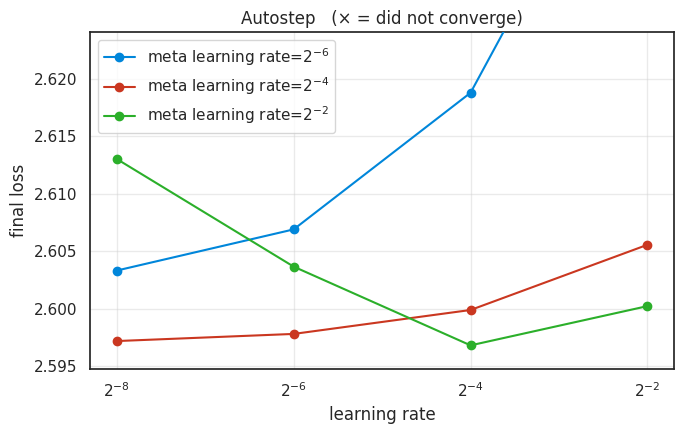

In [ ]:
AUTOSTEP_GRID = {
    'step_size': [2.0 ** e for e in range(-8, -1, 2)],       # 2^-8 .. 2^-2  (initial step-size)
    'meta_step_size': [2.0 ** e for e in range(-6, -1, 2)],  # 2^-6 .. 2^-2
}
run_method_sweep(METHODS['autostep'], AUTOSTEP_GRID, N_SWEEP_SEEDS)
cfgs, runs = load_sweep_data()
autostep_summary = summarize_runs(cfgs, runs, 'autostep', swept_vars(AUTOSTEP_GRID), FINAL_FRACTION, BASELINE_LOSS)
plot_sensitivity(autostep_summary, swept_vars(AUTOSTEP_GRID), 'Autostep')
plt.show()

### Autostep — best configuration learning curve (30 seeds)

[I 2026-07-28 15:16:36,471] Using an existing study with name 'feature_sifting_adaptive_gt/autostep_best' instead of creating a new one.
INFO:mlflow_sweeper.runner:Using existing parent MLflow run: ebbc2045c8674184b52fb1760fa85f55.
INFO:mlflow_sweeper.runner:Study is complete. No more trials to run.


Autostep best: {'learning_rate': 0.0625, 'meta_learning_rate': 0.25}
Reusing cached CSVs (81 runs, no new data to download).


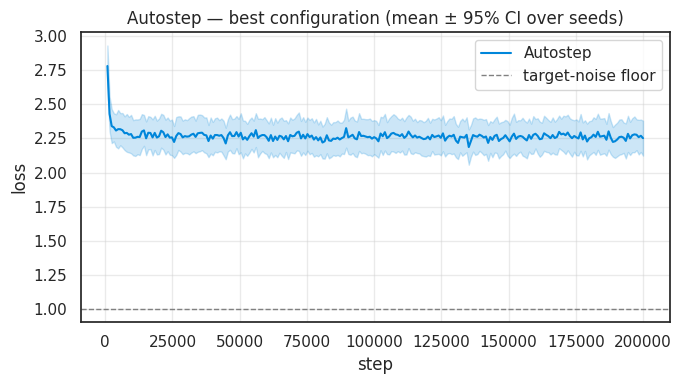

In [7]:
autostep_best = best_hparams(cfgs, runs, METHODS['autostep'], AUTOSTEP_GRID)
print('Autostep best:', autostep_best)
run_method_sweep(METHODS['autostep'], autostep_best, N_CURVE_SEEDS, sweep_name='autostep_best')
cfgs, runs = load_sweep_data()

plt.figure(figsize=(7, 4))
plot_learning_curve(runs, 'autostep_best', label='Autostep', color=get_color_palette(n=3)[0],
                    n_seeds=N_CURVE_SEEDS)
plt.axhline(NOISE_FLOOR_LOSS, ls='--', c='gray', lw=1, label='target-noise floor')
plt.title('Autostep — best configuration (mean ± 95% CI over seeds)')
plt.legend(); plt.tight_layout(); plt.show()

## 2. Autostep + Generate & Test

The simplest generate-and-test rule: every `prune_period` steps, drop the single lowest-magnitude weight
(utility = `|weight|`) and regenerate that slot. Like CBP, but the utility is just the weight magnitude and
pruning fires on a fixed clock rather than a replacement-rate accumulator. Sweeps step-size, meta step-size,
and the prune period.

In [ ]:
class AutostepGT(eqx.Module):
    """Autostep + Generate & Test. Every `prune_period` steps, prune the single lowest-magnitude
    weight (utility = |weight|); the pruned slot is regenerated by the task and its Autostep state
    is reset to initial."""
    optimizer: optax.GradientTransformation = eqx.field(static=True)
    prune_period: int = eqx.field(static=True)
    w: jax.Array
    opt_state: optax.OptState
    step_idx: jax.Array
    prune_mask: jax.Array

    @classmethod
    def init(cls, hparams, key):
        n = N_LEARNER_FEATURES
        optimizer = optax_idbd(init_lr=hparams['step_size'],
                               meta_lr=hparams['meta_step_size'], autostep=True)
        w = jnp.zeros((1, n))
        return cls(optimizer=optimizer, prune_period=int(hparams['prune_period']),
                   w=w, opt_state=optimizer.init(w), step_idx=jnp.array(0),
                   prune_mask=jnp.zeros(n, dtype=bool))

    def step(self, x, y):
        loss, loss_grads = linear_loss_and_grads(self.w, x, y)
        updates, opt_state = self.optimizer.update((loss_grads, x[None, :]), self.opt_state, self.w)
        w = optax.apply_updates(self.w, updates)

        # Every `prune_period` steps, prune the single lowest-magnitude weight.
        step_idx = self.step_idx + 1
        should_prune = (step_idx % self.prune_period) == 0
        utility = jnp.abs(w[0])
        prune_mask = should_prune & (jnp.arange(w.shape[1]) == jnp.argmin(utility))
        w = jnp.where(prune_mask[None, :], 0.0, w)
        opt_state = reset_idbd_state(opt_state, prune_mask)

        return tree_replace(self, w=w, opt_state=opt_state, step_idx=step_idx,
                            prune_mask=prune_mask), loss


AUTOSTEP_GT_DEFAULTS = {'step_size': 2.0 ** -2, 'meta_step_size': 2.0 ** -4,
                        'prune_period': 2 ** 10}
METHODS['autostep_gt'] = MethodSpec('autostep_gt', 'Autostep + G&T', AutostepGT, AUTOSTEP_GT_DEFAULTS)

[I 2026-07-28 15:16:36,836] Using an existing study with name 'feature_sifting_adaptive_gt/autostep_gt' instead of creating a new one.
INFO:mlflow_sweeper.runner:Using existing parent MLflow run: 244ad215b6e74846bd582f08b665e68b.
INFO:mlflow_sweeper.runner:Study is complete. No more trials to run.


Reusing cached CSVs (81 runs, no new data to download).


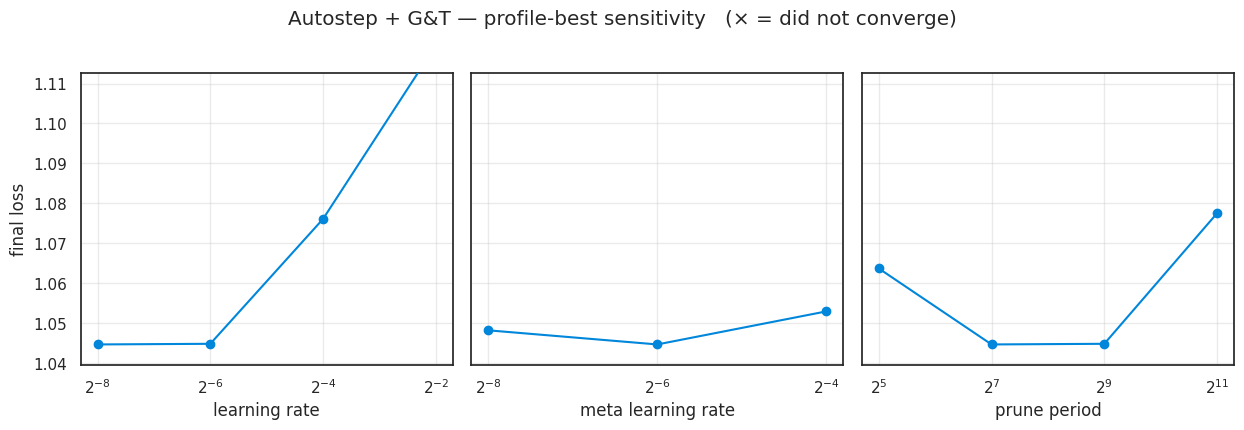

In [ ]:
AUTOSTEP_GT_GRID = {
    'step_size': [2.0 ** e for e in range(-8, -1, 2)],       # 2^-8 .. 2^-2
    'meta_step_size': [2.0 ** e for e in range(-8, -3, 2)],  # 2^-8 .. 2^-4
    'prune_period': [2 ** 5, 2 ** 7, 2 ** 9, 2 ** 11],
}
run_method_sweep(METHODS['autostep_gt'], AUTOSTEP_GT_GRID, N_SWEEP_SEEDS)
cfgs, runs = load_sweep_data()
autostep_gt_summary = summarize_runs(cfgs, runs, 'autostep_gt', swept_vars(AUTOSTEP_GT_GRID), FINAL_FRACTION, BASELINE_LOSS)
plot_sensitivity(autostep_gt_summary, swept_vars(AUTOSTEP_GT_GRID), 'Autostep + G&T')
plt.show()

### Autostep + G&T — best configuration learning curve (30 seeds)

[I 2026-07-28 15:16:37,296] Using an existing study with name 'feature_sifting_adaptive_gt/autostep_gt_best' instead of creating a new one.
INFO:mlflow_sweeper.runner:Using existing parent MLflow run: 1c035f63b7f7499c8a9d114e2694db4c.
INFO:mlflow_sweeper.runner:Study is complete. No more trials to run.


Autostep + G&T best: {'learning_rate': 0.00390625, 'meta_learning_rate': 0.015625, 'prune_period': 128.0}
Reusing cached CSVs (81 runs, no new data to download).


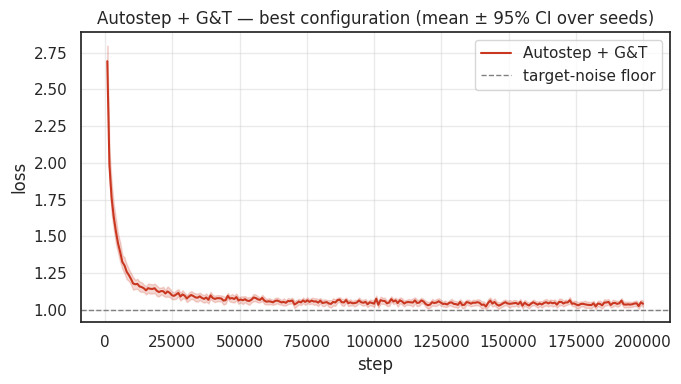

In [10]:
autostep_gt_best = best_hparams(cfgs, runs, METHODS['autostep_gt'], AUTOSTEP_GT_GRID)
print('Autostep + G&T best:', autostep_gt_best)
run_method_sweep(METHODS['autostep_gt'], autostep_gt_best, N_CURVE_SEEDS, sweep_name='autostep_gt_best')
cfgs, runs = load_sweep_data()

plt.figure(figsize=(7, 4))
plot_learning_curve(runs, 'autostep_gt_best', label='Autostep + G&T', color=get_color_palette(n=3)[1],
                    n_seeds=N_CURVE_SEEDS)
plt.axhline(NOISE_FLOOR_LOSS, ls='--', c='gray', lw=1, label='target-noise floor')
plt.title('Autostep + G&T — best configuration (mean ± 95% CI over seeds)')
plt.legend(); plt.tight_layout(); plt.show()

### Autostep + G&T — replacement-rate (prune-period) study

How much does the pruning clock matter? Holding the step-size and meta step-size at the best values found by
the grid sweep above, 30 seeds are run at each prune period in `PRUNE_PERIODS` — one feature replaced every
25, 50, 100, 200, 400, or 800 steps (equivalently a replacement rate of 1/25 … 1/800 features per step, or
`1 / (20 · period)` per feature per step across the 20 candidate slots). Fast replacement searches the
feature space quickly but keeps throwing away features before their weights have settled; slow replacement
is stable but takes a long time to find a good feature set.

## 3. Autostep + Adaptive G&T

The same `|weight|` generate-and-test rule as method 2, but the clock adapts. Every prune event records
*which* slot it hit; if the next prune event hits **the same slot again**, the prune period is multiplied by
`1 + increase_frac` (10% by default: 50 → 55 → 60.5 → 66.6 → …). Hitting the same slot twice in a row means
the feature generated to replace it was immediately the worst candidate again — the generator is not turning
up anything better than what the learner already holds — so search is annealed instead of churning forever
at a fixed rate. The period never shrinks: a prune event landing on a different slot simply leaves it where
it is.

The only extra state over method 2 is the current (fractional) period, a countdown of steps since the last
prune, and the index of the previously pruned slot. No sweep of its own: it starts from method 2's best
step-size, meta step-size, and prune period, with the period growth fraction set to 10%.

In [ ]:
class AutostepAdaptiveGT(eqx.Module):
    """Autostep + Adaptive Generate & Test. Same rule as `AutostepGT` (every `prune_period` steps
    prune the lowest-magnitude weight), except the period grows by `increase_frac` whenever a prune
    event hits the same slot as the previous prune event — i.e. whenever the replacement feature was
    immediately the worst one again, so the search is not paying off. The period only ever grows."""
    optimizer: optax.GradientTransformation = eqx.field(static=True)
    increase_frac: float = eqx.field(static=True)
    w: jax.Array
    opt_state: optax.OptState
    prune_period: jax.Array      # current (fractional) period; grows on a repeated prune
    steps_since_prune: jax.Array
    last_pruned_idx: jax.Array   # slot pruned by the previous prune event (-1 before the first)
    prune_mask: jax.Array

    @classmethod
    def init(cls, hparams, key):
        n = N_LEARNER_FEATURES
        optimizer = optax_idbd(init_lr=hparams['step_size'],
                               meta_lr=hparams['meta_step_size'], autostep=True)
        w = jnp.zeros((1, n))
        return cls(optimizer=optimizer, increase_frac=float(hparams['period_increase_frac']),
                   w=w, opt_state=optimizer.init(w),
                   prune_period=jnp.asarray(float(hparams['prune_period'])),
                   steps_since_prune=jnp.array(0), last_pruned_idx=jnp.array(-1),
                   prune_mask=jnp.zeros(n, dtype=bool))

    def step(self, x, y):
        loss, loss_grads = linear_loss_and_grads(self.w, x, y)
        updates, opt_state = self.optimizer.update((loss_grads, x[None, :]), self.opt_state, self.w)
        w = optax.apply_updates(self.w, updates)

        # Prune the single lowest-magnitude weight once the (fractional) period has elapsed.
        steps_since_prune = self.steps_since_prune + 1
        should_prune = steps_since_prune >= self.prune_period
        pruned_idx = jnp.argmin(jnp.abs(w[0]))
        prune_mask = should_prune & (jnp.arange(w.shape[1]) == pruned_idx)

        # Same slot as the last prune event -> the generator is not beating what we have; slow down.
        repeated = should_prune & (pruned_idx == self.last_pruned_idx)
        prune_period = jnp.where(repeated, self.prune_period * (1.0 + self.increase_frac),
                                 self.prune_period)
        last_pruned_idx = jnp.where(should_prune, pruned_idx, self.last_pruned_idx)
        steps_since_prune = jnp.where(should_prune, 0, steps_since_prune)

        w = jnp.where(prune_mask[None, :], 0.0, w)
        opt_state = reset_idbd_state(opt_state, prune_mask)

        return tree_replace(self, w=w, opt_state=opt_state, prune_period=prune_period,
                            steps_since_prune=steps_since_prune, last_pruned_idx=last_pruned_idx,
                            prune_mask=prune_mask), loss


AUTOSTEP_ADAPTIVE_DEFAULTS = {'step_size': 2.0 ** -2, 'meta_step_size': 2.0 ** -4,
                              'prune_period': 2 ** 10, 'period_increase_frac': BASE_INCREASE_FRAC}
METHODS['autostep_adaptive'] = MethodSpec('autostep_adaptive', 'Autostep + Adaptive G&T',
                                          AutostepAdaptiveGT, AUTOSTEP_ADAPTIVE_DEFAULTS)

### Autostep + Adaptive G&T — 10% period growth (30 seeds)

Method 2's best hyperparameters, with a 10% period increase on every repeated prune.

[I 2026-07-28 15:16:38,470] Using an existing study with name 'feature_sifting_adaptive_gt/autostep_adaptive_best' instead of creating a new one.
INFO:mlflow_sweeper.runner:Using existing parent MLflow run: e7ea846f665141e1b16d082f96a41e88.
INFO:mlflow_sweeper.runner:Study is complete. No more trials to run.


Autostep + Adaptive G&T at: {'learning_rate': 0.00390625, 'meta_learning_rate': 0.015625, 'prune_period': 128.0, 'period_increase_frac': 0.1}
Reusing cached CSVs (81 runs, no new data to download).


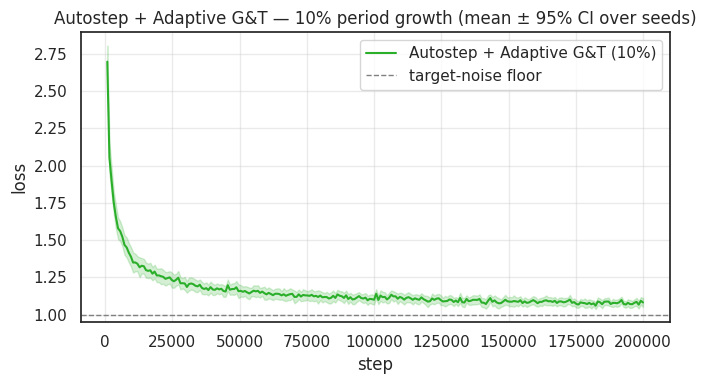

In [13]:
autostep_adaptive_base = {**autostep_gt_best, 'period_increase_frac': BASE_INCREASE_FRAC}
print('Autostep + Adaptive G&T at:', autostep_adaptive_base)
run_method_sweep(METHODS['autostep_adaptive'], autostep_adaptive_base, N_CURVE_SEEDS,
                 sweep_name='autostep_adaptive_best')
cfgs, runs = load_sweep_data()

plt.figure(figsize=(7, 4))
plot_learning_curve(runs, 'autostep_adaptive_best', label='Autostep + Adaptive G&T (10%)',
                    color=get_color_palette(n=3)[2], n_seeds=N_CURVE_SEEDS)
plt.axhline(NOISE_FLOOR_LOSS, ls='--', c='gray', lw=1, label='target-noise floor')
plt.title('Autostep + Adaptive G&T — 10% period growth (mean ± 95% CI over seeds)')
plt.legend(); plt.tight_layout(); plt.show()

### Autostep + Adaptive G&T — period-growth study

How aggressively should the clock anneal? 30 seeds at each growth fraction in `INCREASE_FRACS` (5%, 10%,
20%, 40%, 80%), all from method 2's best step-size / meta step-size / prune period. A small fraction keeps
searching at close to the fixed rate; a large one shuts the search down after a handful of repeated prunes
(at 80%, ten repeats already stretch the period by ~350×).

[I 2026-07-28 15:16:38,816] Using an existing study with name 'feature_sifting_adaptive_gt/autostep_adaptive_fracs' instead of creating a new one.
INFO:mlflow_sweeper.runner:Using existing parent MLflow run: 445121523fec4aadbf2835784bb6162a.
INFO:mlflow_sweeper.runner:Study is complete. No more trials to run.


Reusing cached CSVs (81 runs, no new data to download).


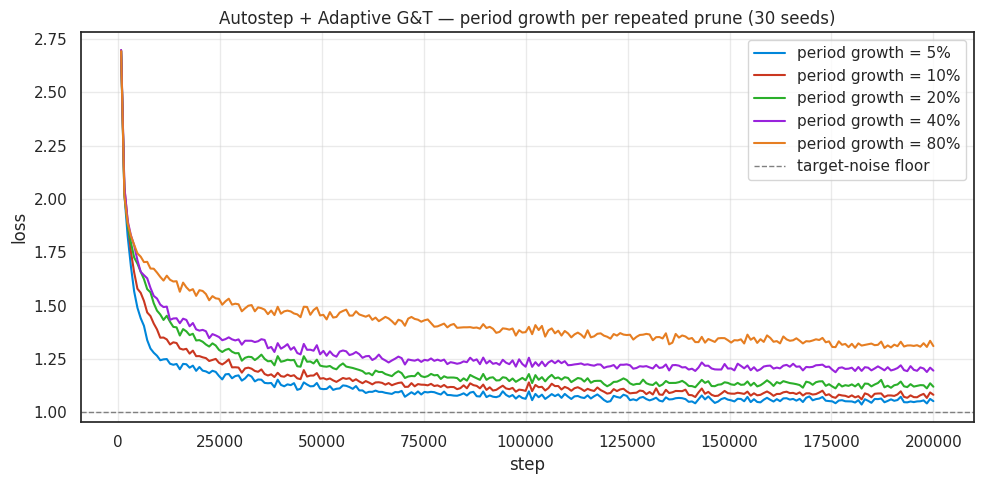

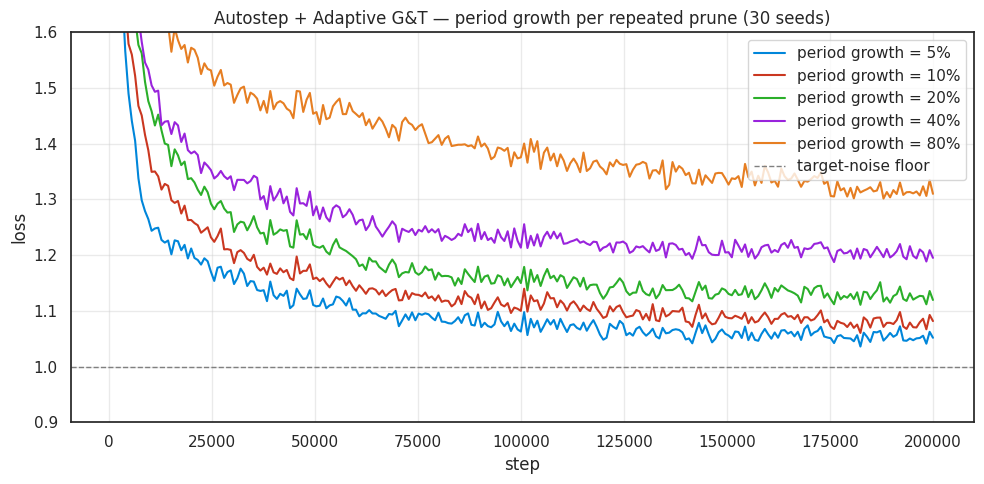

In [14]:
autostep_adaptive_frac_grid = {**autostep_gt_best, 'period_increase_frac': INCREASE_FRACS}
run_method_sweep(METHODS['autostep_adaptive'], autostep_adaptive_frac_grid, N_CURVE_SEEDS,
                 sweep_name='autostep_adaptive_fracs')
cfgs, runs = load_sweep_data()

for zoom in (False, True):
    plt.figure(figsize=(10, 5))
    ax = plt.gca()
    plot_config_curves(cfgs, runs, 'autostep_adaptive_fracs', 'period_increase_frac',
                       lambda v: f'period growth = {v:.0%}', ax=ax)
    ax.axhline(NOISE_FLOOR_LOSS, ls='--', c='gray', lw=1, label='target-noise floor')
    ax.set_title('Autostep + Adaptive G&T — period growth per repeated prune (30 seeds)')
    ax.legend()
    if zoom:
        ax.set_ylim(0.9 * NOISE_FLOOR_LOSS, NOISE_FLOOR_LOSS + 0.6)
    plt.tight_layout(); plt.show()

## All methods — best configurations

The best configuration of each method (already run above with 30 seeds) plotted together. Data is loaded from
the cache, so this cell does not re-run any experiment.

Reusing cached CSVs (81 runs, no new data to download).


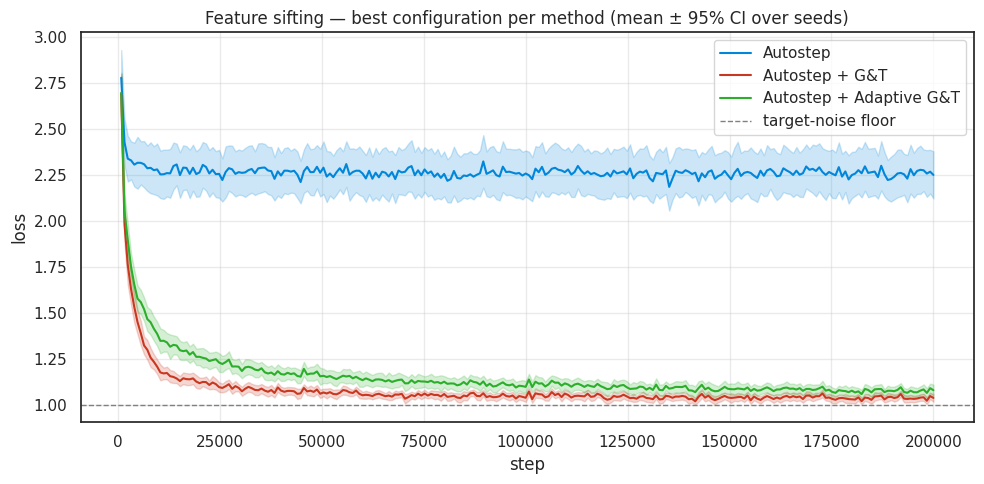

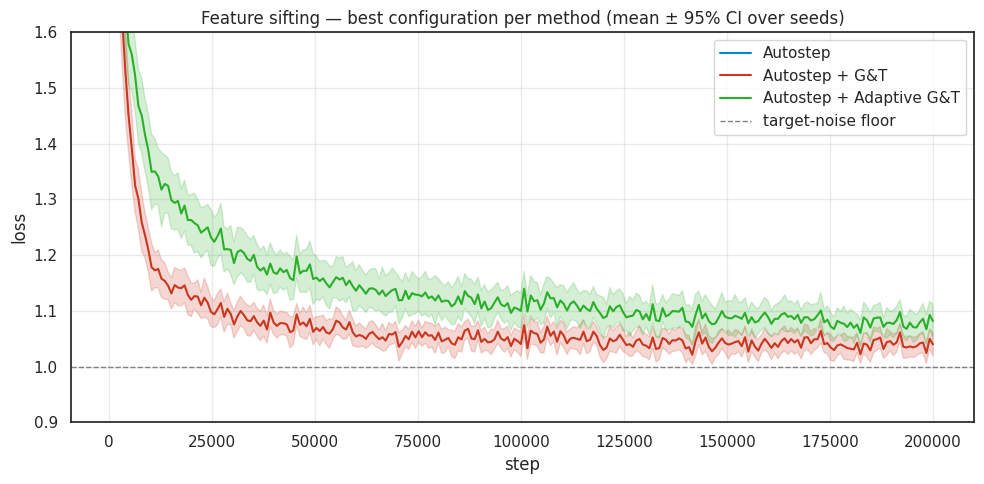

In [15]:
cfgs, runs = load_sweep_data()

best_sweeps = [(m.label, key + '_best') for key, m in METHODS.items()]
colors = get_color_palette(n=len(best_sweeps))

for zoom in (False, True):
    plt.figure(figsize=(10, 5))
    ax = plt.gca()
    for (label, sweep_name), color in zip(best_sweeps, colors):
        if sweep_name in runs:
            plot_learning_curve(runs, sweep_name, label=label, color=color, ax=ax,
                                n_seeds=N_CURVE_SEEDS)
    ax.axhline(NOISE_FLOOR_LOSS, ls='--', c='gray', lw=1, label='target-noise floor')
    ax.set_title('Feature sifting — best configuration per method (mean ± 95% CI over seeds)')
    ax.legend()
    if zoom:
        ax.set_ylim(0.9 * NOISE_FLOOR_LOSS, NOISE_FLOOR_LOSS + 0.6)
    plt.tight_layout(); plt.show()

## Loss floor and pruning rate

Two per-method diagnostics that the sweeps do **not** log (only `loss` is logged). We replay each method's
*best* configuration in-memory over the same 30 seeds and record, at every step:

* the **loss floor** — for each of the 10 unique target features, the lowest noise coefficient among the
  candidate slots currently pointing at it (`1.0` for an uncovered target), summed. It measures the quality
  of the feature set a method has assembled: a good sifter keeps low-noise candidates and drives the floor
  down, while plain Autostep (no pruning) stays at the fixed floor of its initial random features. (This is a
  feature-quality floor in units of summed noise coefficient, not a squared-error lower bound, so it is shown
  on its own axis rather than under the loss curves.)
* the **pruning rate** — the number of candidate slots regenerated per step (log scale; a method that never
  prunes is flagged in the legend). This is where Adaptive G&T is visible directly: its rate decays as the
  period grows, while fixed G&T is flat at `1 / prune_period`.

INFO:2026-07-28 15:16:40,047:jax._src.xla_bridge:752: Unable to initialize backend 'tpu': INTERNAL: Failed to open libtpu.so: libtpu.so: cannot open shared object file: No such file or directory
INFO:jax._src.xla_bridge:Unable to initialize backend 'tpu': INTERNAL: Failed to open libtpu.so: libtpu.so: cannot open shared object file: No such file or directory


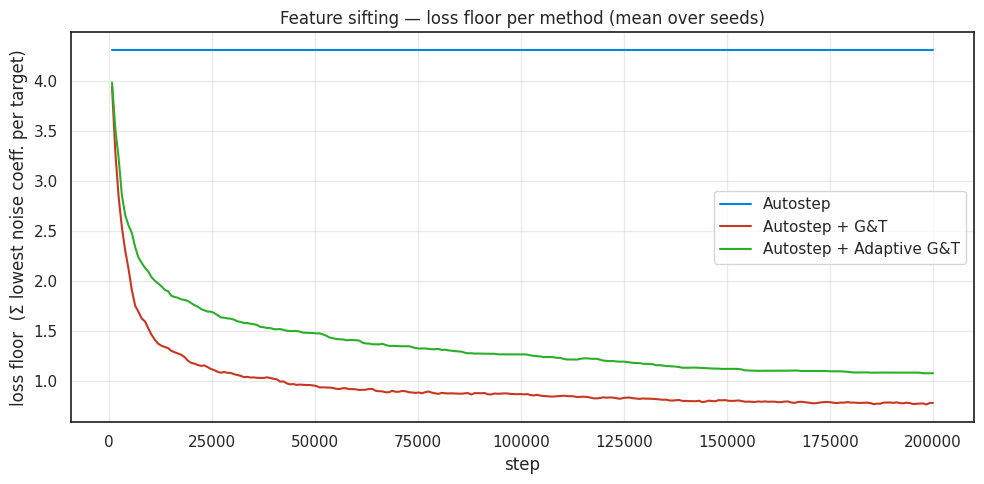

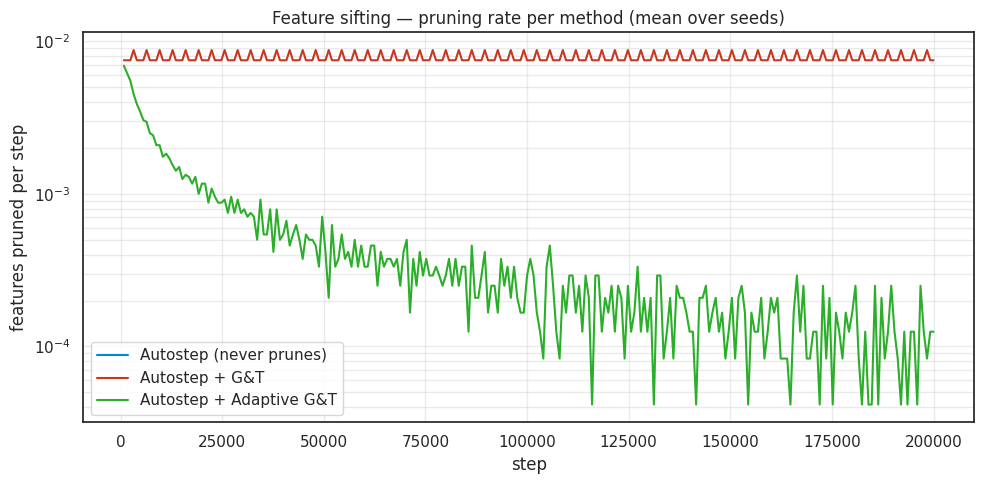

In [16]:
# Replay each method's best config in-memory, tracking the loss floor and pruning rate (neither is
# logged during the sweeps). Same hyperparameters / seeds / steps as the logged best-config curves,
# so these diagnostics correspond exactly to the loss curves plotted above.

def best_config_hparams(spec):
    """Best hyperparameters of `<name>_best`, read back from the cached sweep params (swept values
    overriding the method's non-swept defaults)."""
    if spec.name + '_best' not in cfgs:
        return dict(spec.defaults)
    row = cfgs[spec.name + '_best'].iloc[0]
    swept = {}
    for k in spec.defaults:
        if k in row.index:
            try:
                v = float(row[k])
            except (TypeError, ValueError):
                continue
            if np.isfinite(v):
                swept[k] = v
    return {**spec.defaults, **swept}


def run_with_diagnostics(method_cls, hparams, n_seeds):
    """Like `run_all_seeds`, but each step also emits the loss floor and the prune count."""
    def run_one_seed(seed_key):
        task_key, init_key = jax.random.split(seed_key)
        task = FeatureSiftingTask(N_TARGET_FEATURES, N_LEARNER_FEATURES, TARGET_NOISE_STD, key=task_key)
        state = method_cls.init(hparams, init_key)

        def scan_step(carry, _):
            task, state = carry
            task, (x, y) = task.step(state.prune_mask)
            state, _ = state.step(x, jnp.squeeze(y))
            return (task, state), (noise_floor(task), jnp.sum(state.prune_mask))

        _, out = jax.lax.scan(scan_step, (task, state), length=NUM_STEPS)
        return out   # (floor, n_pruned), each (NUM_STEPS,)

    seed_keys = jax.random.split(jax.random.PRNGKey(BASE_SEED), n_seeds)
    return jax.jit(jax.vmap(run_one_seed))(seed_keys)


def bin_over_seeds(arr, n_points=N_LOG_POINTS):
    """Bin (n_seeds, n_steps) into (n_points,) window-means, then mean over seeds — matching the
    binning `log_run` applies to the logged loss curve, so the x-axes line up."""
    arr = np.asarray(arr)
    n_seeds, n_steps = arr.shape
    w = n_steps // n_points
    binned = arr[:, :w * n_points].reshape(n_seeds, n_points, w).mean(axis=2)
    return np.arange(1, n_points + 1) * w, binned.mean(axis=0)


diagnostics = {}
for key, spec in METHODS.items():
    floor, n_pruned = run_with_diagnostics(spec.cls, best_config_hparams(spec), N_CURVE_SEEDS)
    steps, floor_curve = bin_over_seeds(floor)
    _, prune_curve = bin_over_seeds(n_pruned)
    diagnostics[key] = {'steps': steps, 'floor': floor_curve, 'prune_rate': prune_curve}

colors = get_color_palette(n=len(METHODS))   # same order/palette as the loss comparison above

# --- Loss floor per method ---
plt.figure(figsize=(10, 5))
ax = plt.gca()
for (key, spec), color in zip(METHODS.items(), colors):
    d = diagnostics[key]
    ax.plot(d['steps'], d['floor'], color=color, label=spec.label)
ax.set_xlabel('step'); ax.set_ylabel('loss floor  (Σ lowest noise coeff. per target)')
ax.set_title('Feature sifting — loss floor per method (mean over seeds)')
ax.grid(True, alpha=0.4); ax.legend()
plt.tight_layout(); plt.show()

# --- Pruning rate per method (log scale; never-pruning methods flagged in the legend) ---
plt.figure(figsize=(10, 5))
ax = plt.gca()
for (key, spec), color in zip(METHODS.items(), colors):
    d = diagnostics[key]
    if np.any(d['prune_rate'] > 0):
        ax.plot(d['steps'], np.where(d['prune_rate'] > 0, d['prune_rate'], np.nan),
                color=color, label=spec.label)
    else:
        ax.plot([], [], color=color, label=f'{spec.label} (never prunes)')
ax.set_yscale('log')
ax.set_xlabel('step'); ax.set_ylabel('features pruned per step')
ax.set_title('Feature sifting — pruning rate per method (mean over seeds)')
ax.grid(True, alpha=0.4, which='both'); ax.legend()
plt.tight_layout(); plt.show()